## **Day 5 — Advancing the Core Model & Sprint Review**

*This notebook is a continuation of `Notebook7.4` and the two notebooks complete each other.*

**Project goal:**

A news classifier that sorts news based on *title* and *description* into Four distict categories; World, Sports, Business and Sci/Tech.

## **Core Architectuer for the project**

**Core model decision:**

DistilBERT - transformer - will serve as this project's core model.

**Reasoning:**

DistilBERT reached a **94.5% test accuracy and F1 macro of 0.945** versus *91.5% for the Day 3 LSTM* baseline on the same AG news dataset. The 3 point gap was achieved with fewer training epochs with no overfitting. Beyond the raw metric gap, **self-attention lets the model weigh every word**  in a headline or description against every other word directly, rather than compressing the sequence step by step into one hidden state - *this maters for news text where the topic defining word isn't near the start of the sentence*. Given its stronger accuracy, faster convergence  and practical training time - around 6.5 mins  on a single Cloab T4 GPU - **DistiBERT is the clear choice for this project's core model**.

## **Fine-tuned DistilBERT Baseline Results**

The following baseline results were obtained in *Notebook6.4* and are documented here rather than re-executed to conserve limited GPU resources in this notebook. The model was trained and evaluated on the AG News classification dataset.

|| Test Accuracy | F1 Macro | Notes |
|---|---|---|---|
| **DistilBERT** | 94.5% | 0.945 | 1 epoch, default hyperparameters (lr=5e-5, batch=16), training loss - 0.189, validation loss - 0.173; no overfitting observed |


**Reproducability Note:**

The runs were not repeated in this session due to *GPU availability constraints*. The tuning work below builds on the DistilBERT baseline's untuned hyperparameters as a starting point rather than retraining the model from scratch.

## **Imports**

In [1]:
! pip install mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 31.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score
import numpy as np
from transformers import pipeline, DataCollatorWithPadding
import mlflow

## **Uploading the Dataset**

In [3]:
from google.colab import drive
import zipfile

drive.mount('/content/drive')

train_path="/content/drive/MyDrive/train.csv"
test_path="/content/drive/MyDrive/test.csv"

train_df = pd.read_csv(train_path, header=None, names=["label", "title", "description"])
test_df = pd.read_csv(test_path, header=None, names=["label", "title", "description"])

print("Extraction complete!")

Mounted at /content/drive
Extraction complete!


## **Pre-trained Pipeline**

In [4]:
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

sample_text = "The central bank raised interest rates again this week amid inflation concerns."
labels=["World", "sports", "Business", "Sci/Tech"]

result = classifier(sample_text, candidate_labels=labels)
print(result["labels"][0], "--->", round(result["scores"][0], 3))

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.63GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

World ---> 0.454


## **Preprocessing**

In [5]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (120001, 3)
Test shape: (7601, 3)


In [6]:
train_df["label"] = pd.to_numeric(train_df["label"], errors="coerce")
test_df["label"] = pd.to_numeric(test_df["label"], errors="coerce")


train_df = train_df.dropna(subset=["label"]).reset_index(drop=True)
test_df = test_df.dropna(subset=["label"]).reset_index(drop=True)

In [7]:
print(train_df["label"].unique())
print(test_df["label"].unique())

[3. 4. 2. 1.]
[3. 4. 2. 1.]


In [8]:
train_df.columns

Index(['label', 'title', 'description'], dtype='object')

In [9]:
train_df["text"] = train_df["title"] + " " + train_df["description"]
test_df["text"] = test_df["title"] + " " + test_df["description"]

train_df["label"] = train_df["label"].astype(int) - 1
test_df["label"] = test_df["label"].astype(int) - 1

train_ds = Dataset.from_pandas(train_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])

model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
  return tokenizer(batch["text"], max_length=128, truncation=True)

train_ds = train_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def compute_metrics(eval_pred):
  logits, labels = eval_pred
  preds = np.argmax(logits, axis=1)
  return {
      "accuracy": accuracy_score(labels, preds),
      "f1_macro": f1_score(labels, preds, average="macro")
      }

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/120000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

## **Tuning with MLflow logging**

In [10]:
mlflow.set_experiment("ag_news_distilbert_sprint2")
param_grid = [
    {"learning_rate": 3e-5, "num_train_epochs": 2, "per_device_train_batch_size":16},
    {"learning_rate": 2e-5, "num_train_epochs": 2, "per_device_train_batch_size":32},
]

results = []

for i, params in enumerate(param_grid):
  with mlflow.start_run(run_name=f"run{i}"):
    mlflow.log_params(params)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

    training_args  = TrainingArguments(
        output_dir=f"/content/tunning_run{i}",
        per_device_train_batch_size=params["per_device_train_batch_size"],
        per_device_eval_batch_size=32,
        learning_rate= params["learning_rate"],
        num_train_epochs=params["num_train_epochs"],
        fp16=True,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=200
    )

    trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics
    )

    trainer.train()
    metrics = trainer.evaluate()

    mlflow.log_metrics({
        "accuracy": metrics["eval_accuracy"],
        "f1_macro": metrics["eval_f1_macro"],
        "eval_loss": metrics["eval_loss"],
    })

    trainer.save_model(f"/content/drive/MyDrive/ag_news_tuning/run{i}")
    results.append({**params, **metrics})

results_df= pd.DataFrame(results)
print(results_df.sort_values("eval_accuracy", ascending=False))

2026/09/03 08:14:38 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/03 08:14:38 INFO mlflow.store.db.utils: Updating database tables
2026/09/03 08:14:41 INFO mlflow.tracking.fluent: Experiment with name 'ag_news_distilbert_sprint2' does not exist. Creating a new experiment.


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.176012,0.170631,0.940789,0.940840
2,0.132206,0.169038,0.945000,0.945029


Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.132206,0.169038,2,0.945000,0.945029


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

   learning_rate  num_train_epochs  per_device_train_batch_size  eval_loss  \
0        0.00003                 2                           16   0.182628   
1        0.00002                 2                           32   0.169038   

   eval_accuracy  eval_f1_macro  
0       0.948026       0.948034  
1       0.945000       0.945029  


In [11]:
best_idx = results_df["eval_accuracy"].idxmax()
print("Best config:\n", results_df.loc[best_idx])

Best config:
 learning_rate                   0.000030
num_train_epochs                2.000000
per_device_train_batch_size    16.000000
eval_loss                       0.182628
eval_accuracy                   0.948026
eval_f1_macro                   0.948034
Name: 0, dtype: float64


## **Hyperparameter Tuning Results**

Two configrations were tuned via MLflow-logged runs - learning rate & batch size, building on the Sprint 1 untuned DistilBERT baseline.

| Run | Learning Rate | Epochs | Batch Size | Final Accuracy | Finak F1 Macro | Final Evaluation Loss |
|---|---|---|---|---|---|---|
| Baseline | 5e-5 | 1 | 16 | 94.5% | 0.945 | 0.173 |
| 0 | 3e-5 | 2 | 16 | **94.8%** | **0.948** | 0.182 |
| 1 | 2e-5 | 2 | 32 | 94.5% | 0.945 | **0.169** |

**Observation:** Run 0 achieved the highest accuracy of the sprint. but it's validation loss increased between epochs even as accuracy improved which is an overfitting signal. Run 1 showed the opposite pattern; validation loss decreased for both epochs, but accuracy landed marginally below the untuned baseline.

**Run 0 is selected as the Sprint 2 model** based on its **accuracy improvement**. The *loss trend is still regarded as a risk factor* if training continues beyond 2 epochs.


## **Metric Table**

In [13]:
comparison = {
    "Week 6 Baseline": None,
    "Sprint 1 Network - LSTM": 0.9182,
    "Sprint 2 Baseline - untuned DitilBERT": 0.945,
    "Sprint 2 Model - tuned, lr = 3e-5": 0.948
}

comp_df = pd.DataFrame(list(comparison.items()), columns = ["Model", "Accuracy"])
print(comp_df)

                                   Model  Accuracy
0                        Week 6 Baseline       NaN
1                Sprint 1 Network - LSTM    0.9182
2  Sprint 2 Baseline - untuned DitilBERT    0.9450
3      Sprint 2 Model - tuned, lr = 3e-5    0.9480


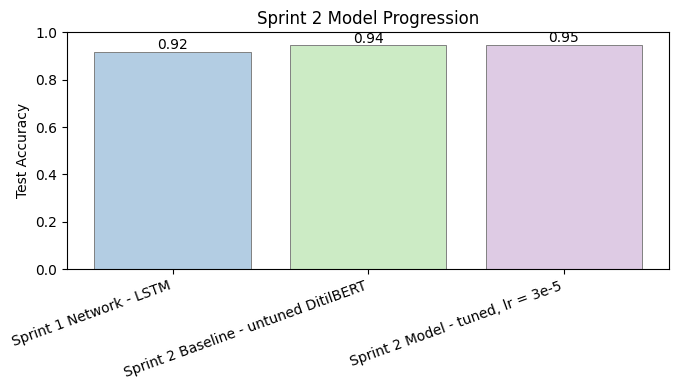

In [18]:
colors = plt.cm.Pastel1(range(len(comp_df)))

plt.figure(figsize=(7, 4))
bars = plt.bar(comp_df["Model"], comp_df["Accuracy"], color=colors, edgecolor="gray", linewidth=0.7)
plt.ylabel("Test Accuracy")
plt.title("Sprint 2 Model Progression")
plt.ylim(0,1)
plt.xticks(rotation=20, ha="right")

for bar, val in zip(bars, comp_df["Accuracy"]):
  if val is not None:
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}", ha="center")
plt.tight_layout()
plt.show()

The table and chart above track this model's accuracy across four checkpoints,  from initial baseline through Sprint 2 tuning. The Sprint 1 *LSTM  established the first working model*; switching to DistilBERT  with default settings delivered *a good jump*, confirming the transformer architecture decision from Sprint 1. The Sprint 2 h**yperparameter tuning pushed the transformer further to 94.8%**, a smaller but noticable gain, with the downside that this run's  validation loss rose slightly between epochs. This rise has to be monitored under 3 epochs to detect overfitting. *The week 6 baseline was included for continuity but was evaluated on a different metric* (ROC-AUC), so it isn't comparable to the accuracy figures here.